In [1]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import aplpy

import pandas as pd
import sys
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch

sys.path.append("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/process_tools")
from cut_resize_tools import *
from Astronomy import *

In [2]:
rank_csv_path = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/rank_catalogue/MWP_Rank*.csv")
rank_csv_path.sort()

In [3]:
# 2. FITSファイルのリストを取得
fits_files = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/*.fits")
fits_files.sort()
integ_fits_files = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/FUGIN/mom0/FGN_*_2x2_12CO_v1.00_cube.pk_vsmooth_2.0_xysmooth_2.0_thresh_700.0_sigma_3.0_mom0.fits")
integ_fits_files.sort()

In [4]:
# 定数の入力
width_half = 30 #使用速度の半分の値
cutting_ratio = 2 #バブルの切り取り範囲の余白設定(2➡︎2倍の大きさで切り取る)

#処理後カタログを格納する変数の作成
rank_1_processed = 0
rank_2_processed = 0
rank_3_processed = 0
rank_catalogs = [rank_1_processed, rank_2_processed, rank_3_processed] 
rank_catalog_num = len(rank_catalogs)

In [5]:
for rank_num in range(rank_catalog_num):
    rank_csv = pd.read_csv(rank_csv_path[rank_num])

    # 1. カタログの読み込みとバブルの境界領域の計算
    df = rank_csv
    
    # Reff（有効半径）が分角(arcmin)であると仮定し、度に変換して境界を計算
    # cutting_ratio = 2 に相当する幅（半径の2倍）を確保して矩形を定義します
    df['radius_deg'] = (df['Reff']/60) * cutting_ratio 
    
    df['glon_min'] = df['GLON'] - df['radius_deg']
    df['glon_max'] = df['GLON'] + df['radius_deg']
    df['glat_min'] = df['GLAT'] - df['radius_deg']
    df['glat_max'] = df['GLAT'] + df['radius_deg']
    
    # 処理完了を管理するフラグと合計強度の格納列を追加
    df['processed'] = False
    df['total_intensity'] = np.nan

    
    # バブル領域の強度計算開始
    for i, fits_file in enumerate(fits_files):
    # まだ処理されていないバブルを抽出
        pending_bubbles = df[~df['processed']]
        if pending_bubbles.empty:
            break # 全てのバブルの処理が完了した場合は終了
    
        with fits.open(fits_file) as hdul:
            data = hdul[0].data
            cube_header = hdul[0].header
            cube_wcs = WCS(cube_header)
    
        integ_fits = integ_fits_files[i]
        with fits.open(integ_fits) as hdui:
            integ_header = hdui[0].header
            wcs = WCS(integ_header)
    
            # 3次元データ (Velocity, GLAT, GLON) の形状を取得
            n_y, n_x = data.shape[1:3]
    
            fits_l_min, fits_b_min = wcs.all_pix2world(n_x, 0, 0)
            fits_l_max, fits_b_max = wcs.all_pix2world(0, n_y, 0)
            
            # 現在のFITS領域内に完全に含まれるバブルを抽出
            contained = pending_bubbles[
                (pending_bubbles['glon_min'] >= fits_l_min) & 
                (pending_bubbles['glon_max'] <= fits_l_max) & 
                (pending_bubbles['glat_min'] >= fits_b_min) & 
                (pending_bubbles['glat_max'] <= fits_b_max)
            ]
            
            for idx, row in contained.iterrows():
                # バブルの矩形領域の最小・最大頂点をピクセル座標に変換
                world_coords = [
                    [row['glon_min'], row['glat_min'], 0],
                    [row['glon_max'], row['glat_max'], 0]
                ]
                pix_coords = cube_wcs.world_to_pixel_values(world_coords)
                
                x_coords = [p[0] for p in pix_coords]
                y_coords = [p[1] for p in pix_coords]
                
                # ピクセル座標を整数化し、画像範囲外にはみ出さないようクリップする
                x_min_pix = max(0, int(np.floor(min(x_coords))))
                x_max_pix = min(n_x, int(np.ceil(max(x_coords))))
                y_min_pix = max(0, int(np.floor(min(y_coords))))
                y_max_pix = min(n_y, int(np.ceil(max(y_coords))))
                
                # 全速度チャンネルを対象に3次元スライス
                cutting_data = data[:, y_min_pix:y_max_pix, x_min_pix:x_max_pix]
                mean = np.nanmean(cutting_data.copy(), axis=(1, 2))
                max_intens_v = np.argmax(mean)
                start_v = max_intens_v - width_half
                end_v = max_intens_v + width_half
                cutting_data = cutting_data[start_v:end_v, :, :]
                # print(cutting_data.shape)
                
                # 欠損値(NaN)を除外して合計強度を算出
                total_val = np.nansum(cutting_data)
                
                # 結果をデータフレームに記録し、処理済みとする
                df.at[idx, 'total_intensity'] = total_val
                df.at[idx, 'processed'] = True
    # 処理後カタログの保存
    rank_catalogs[rank_num] = df

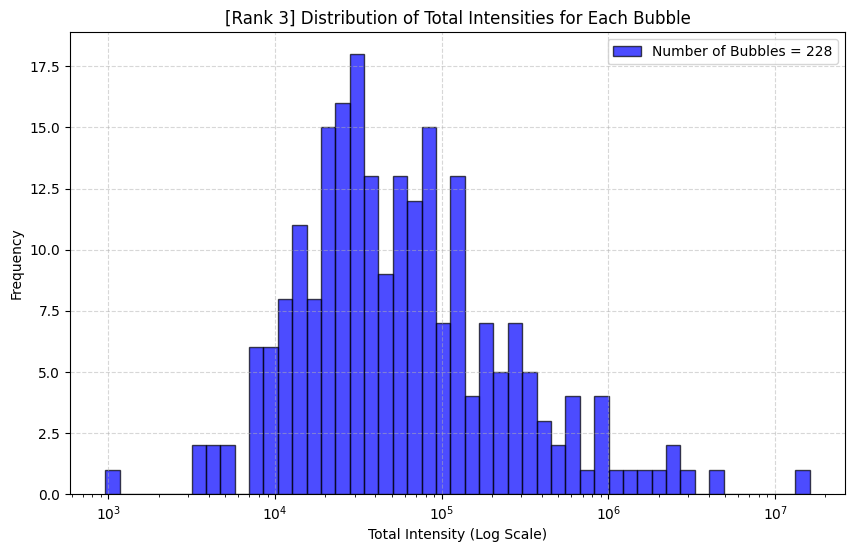

In [6]:
df = rank_catalogs[0]

plt.figure(figsize=(10, 6))
valid_intensities = df['total_intensity'].dropna()
positive_intensities = valid_intensities[valid_intensities > 0]

# データ数(N)を取得
N = len(positive_intensities)

min_val = positive_intensities.min()
max_val = positive_intensities.max()
log_bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)

# label引数で凡例用のテキスト（データ数）を指定
plt.hist(positive_intensities, bins=log_bins, color='blue', alpha=0.7, edgecolor='black', label=f'Number of Bubbles = {N}')

plt.xscale('log')
plt.xlabel('Total Intensity (Log Scale)')
plt.ylabel('Frequency')
plt.title(f'[Rank {rank_num+1}] Distribution of Total Intensities for Each Bubble')
plt.grid(True, linestyle='--', alpha=0.5)

# 凡例を表示
plt.legend()
# plt.savefig(f"[Rank{rank_num+1}]_Distribution_of_Total_Intensities_for_Each_Bubble")
plt.show()